
# Credit Card Fraud Detection

This project trains and evaluates machine learning models for credit card fraud detection using the provided `fraudTrain.csv` and `fraudTest.csv` files.

The goal is to build a model that can detect fraudulent transactions while keeping false fraud alerts reasonable.

## Imports

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# model selection
from sklearn.model_selection import RandomizedSearchCV

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# file paths
from pathlib import Path

## Plot Settings

In [2]:
# consistent plot style for the notebook
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Project Paths

In [3]:
# dataset paths
DATA_DIR = Path("data/archive")
TRAIN_DATA_PATH = DATA_DIR / "fraudTrain.csv"
TEST_DATA_PATH = DATA_DIR / "fraudTest.csv"

# folders for saved outputs
FIG_DIR = Path("reports/figures")
TABLE_DIR = Path("reports/tables")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the Data

The dataset already provides a training file and a testing file, so the two files are kept separate. The training set is used to fit the models, and the testing set is used only for final evaluation.

In [4]:
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (1296675, 23)
Testing shape: (555719, 23)


## 2. Initial Data Check

Before modeling, I check the structure of the dataset, missing values, duplicate rows, and the target distribution.

### Inspect Data

In [5]:

train_df.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [7]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [8]:
print("Missing values in training set:")
print(train_df.isnull().sum())

print("\nDuplicate rows in training set:")
print(train_df.duplicated().sum())

Missing values in training set:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Duplicate rows in training set:
0


### Target Balance

In [9]:
print("Training target distribution:")
print(train_df["is_fraud"].value_counts())

print("\nTraining target percentage:")
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(test_df["is_fraud"].value_counts())

print("\nTesting target percentage:")
print(test_df["is_fraud"].value_counts(normalize=True) * 100)

Training target distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Training target percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

Testing target distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Testing target percentage:
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

The fraud class is expected to be much smaller than the non-fraud class. Because of that, accuracy alone will not be enough to evaluate the models.

### Class Distribution Plot

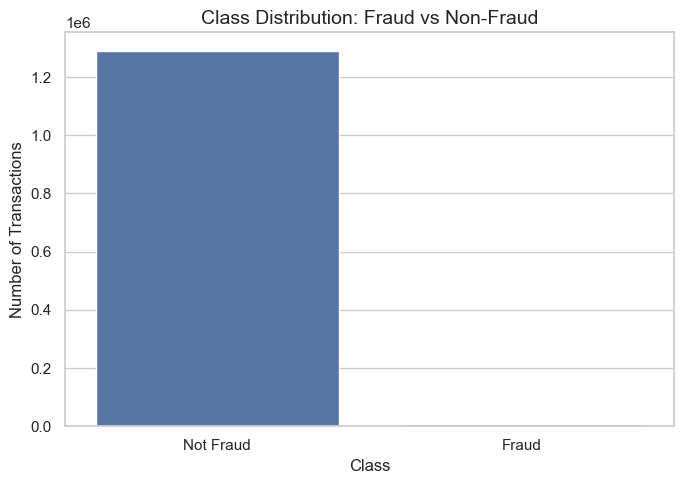

In [10]:
class_counts = train_df["is_fraud"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=300)
plt.show()

### Create Log Amount for EDA

In [11]:
# log amount makes the transaction amount easier to compare because the raw amount has large outliers
train_df["log_amt"] = np.log1p(train_df["amt"])
test_df["log_amt"] = np.log1p(test_df["amt"])

### Log Amount Plot

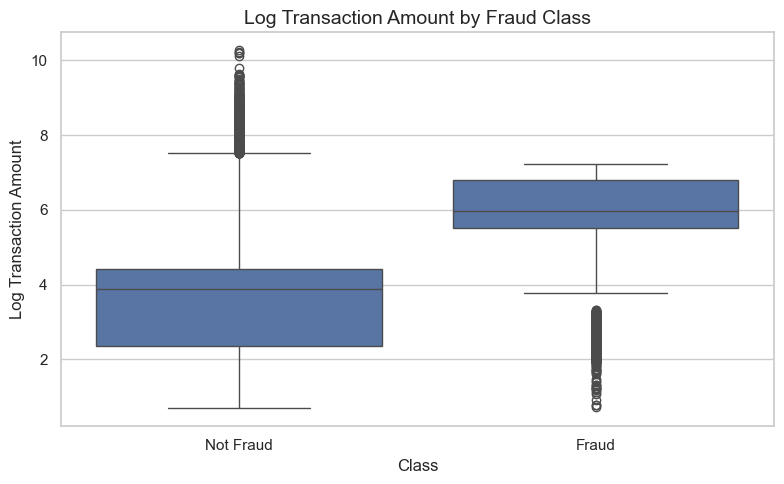

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_df,
    x="is_fraud",
    y="log_amt"
)

plt.title("Log Transaction Amount by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Log Transaction Amount")
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.tight_layout()
plt.savefig(FIG_DIR / "log_amount_by_fraud_class.png", dpi=300)
plt.show()

### Fraud Rate by Category

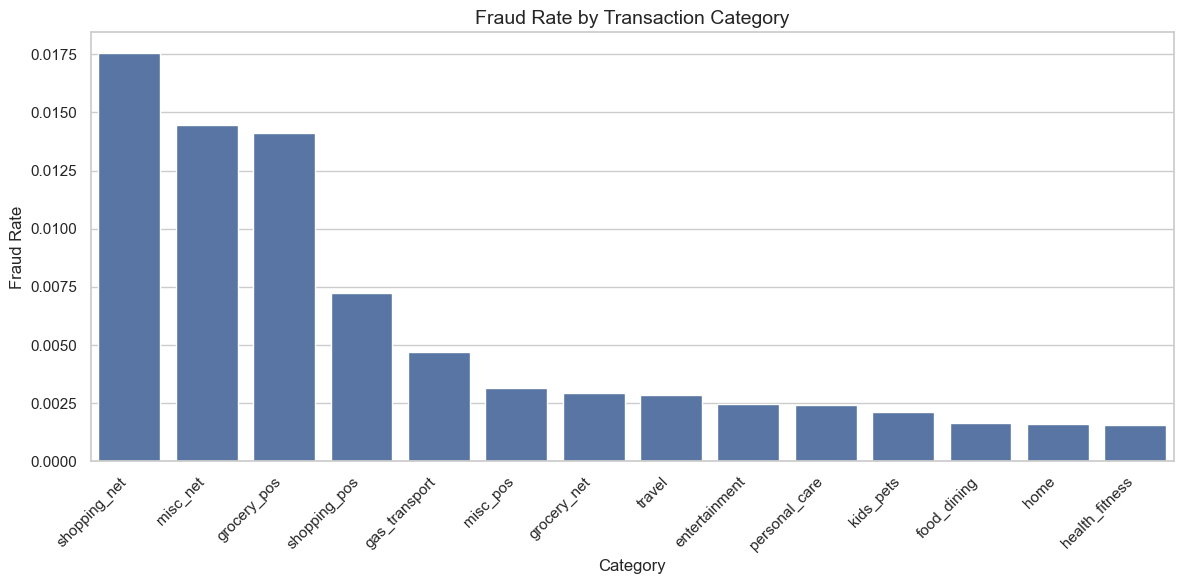

In [13]:
category_fraud_rate = (
    train_df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_fraud_rate.index,
    y=category_fraud_rate.values
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fraud_rate_by_category.png", dpi=300)
plt.show()

## 4. Feature Engineering

The raw date columns are converted into useful numeric features. The model cannot directly use full datetime strings, so I extract transaction hour, day, month, day of week, and customer age.

### Feature Engineering

In [14]:
# feature engineering function to create new features from the existing ones. This includes extracting time-based features from the transaction date, calculating the customer's age at the time of the transaction, and applying a log transformation to the transaction amount to reduce skewness.
def feature_engineering(df):
    df = df.copy()

    # convert date columns
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    # transaction time features
    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_day"] = df["trans_date_trans_time"].dt.day
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

    # customer age at the time of the transaction
    df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

    # log transform for transaction amount
    df["log_amt"] = np.log1p(df["amt"])

    return df

In [15]:
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

train_df.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,log_amt,transaction_hour,transaction_day,transaction_month,transaction_dayofweek,age
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1325376018,36.011293,-82.048315,0,1.786747,0,1,1,1,31
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1325376044,49.159047,-118.186462,0,4.684259,0,1,1,1,41


### Fraud Rate by Hour

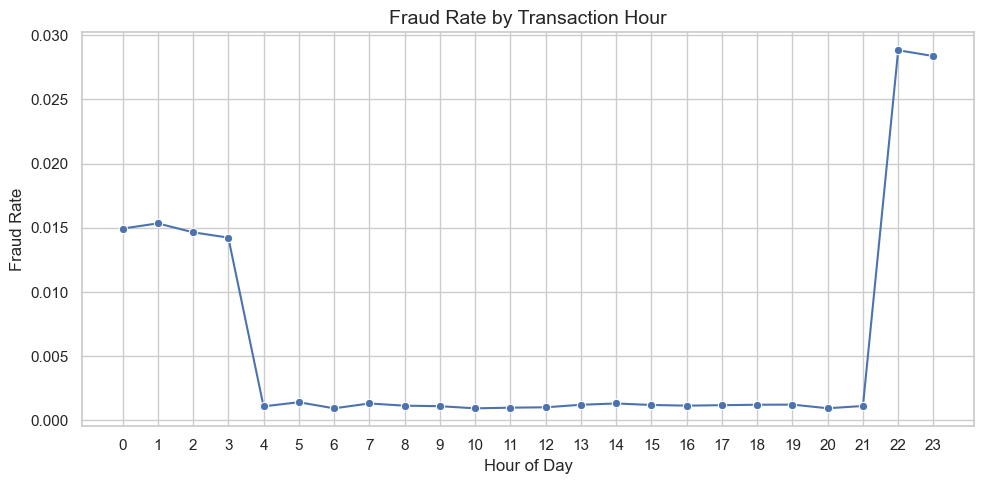

In [16]:
hourly_fraud_rate = (
    train_df.groupby("transaction_hour")["is_fraud"]
    .mean()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.savefig(FIG_DIR / "fraud_rate_by_hour.png", dpi=300)
plt.show()

## 5. Remove Columns Not Used for Modeling

Some columns are identifiers or personal information. They are not useful for general fraud prediction and can cause overfitting, so they are removed.

### Drop Columns

In [17]:
drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num",
    "first",
    "last",
    "street",
    "trans_num",
    "dob",
    "unix_time"
]

# only drop columns that actually exist
drop_cols = [col for col in drop_cols if col in train_df.columns]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print("Training columns after dropping:")
print(train_df.columns.tolist())

Training columns after dropping:
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'log_amt', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'age']


## 6. Split Features and Target

The target column is `is_fraud`. The provided training file is used for training, and the provided testing file is used for final evaluation.

### X and y

In [18]:
X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1296675, 19)
y_train: (1296675,)
X_test: (555719, 19)
y_test: (555719,)


## 7. Preprocessing

Numeric columns are scaled. Categorical columns are one-hot encoded so the models can use them.

### Numeric and Categorical Columns

In [19]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'log_amt', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'age']

Categorical columns:
['merchant', 'category', 'gender', 'city', 'state', 'job']


In [20]:
print("Unique values in categorical columns:")
for col in categorical_cols:
    print(col, X_train[col].nunique())

Unique values in categorical columns:
merchant 693
category 14
gender 2
city 894
state 51
job 494


### Preprocessor

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## 8. Evaluation Helper Functions

These helper functions keep the model evaluation and plots consistent.

### Helper Functions

In [22]:
# function to evaluate model performance using various metrics and print a classification report and confusion matrix. It also calculates the ROC AUC score if probability predictions are provided.
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    }

    print(model_name)
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    if y_proba is not None:
        print("ROC AUC:", result["ROC AUC"])

    return result

In [23]:
# function to plot confusion matrix using seaborn heatmap. It takes the true labels, predicted labels, title for the plot, and filename to save the figure.
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Fraud", "Fraud"],
        yticklabels=["Not Fraud", "Fraud"]
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.show()

## 9. Baseline Models

I first train several baseline models using the same preprocessing pipeline. This gives a fair starting comparison before tuning any model.

### Baseline Models

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

In [ ]:
baseline_results = []

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    result = evaluate_model(name, y_test, y_pred, y_proba)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.sort_values(by="F1 Score", ascending=False)

Training Logistic Regression...
Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.02      0.33      0.04      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.63      0.50    555719
weighted avg       0.99      0.93      0.96    555719

Confusion Matrix:
[[517364  36210]
 [  1437    708]]
ROC AUC: 0.6445528161595029
Training Decision Tree...
Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.65      0.73      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.82      0.86      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Confusion Matrix:
[[552732    842]
 [   578   1567]]
ROC AUC: 0.8645075526717367
Training Random Forest...


## 10. Tune Random Forest

Random Forest performed well as a baseline model, so I tune it using RandomizedSearchCV. RandomizedSearchCV is used instead of GridSearchCV because the dataset is large.

### Random Forest Tuning

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

In [ ]:
print("Best Random Forest parameters:")
print(rf_random_search.best_params_)

print("\nBest cross-validation F1 score:")
print(rf_random_search.best_score_)

### Evaluate Tuned Random Forest

In [ ]:
best_rf_model = rf_random_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
)

In [ ]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Confusion Matrix - Tuned Random Forest",
    "confusion_matrix_tuned_random_forest.png"
)

## 11. Tune Random Forest Threshold

The default classification threshold is 0.50. I test several thresholds to see if a different cutoff improves the F1-score.

### Random Forest Threshold Check

In [ ]:
rf_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

rf_threshold_results = []

for threshold in rf_thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    rf_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold),
        "False Positives": confusion_matrix(y_test, y_pred_threshold)[0][1],
        "False Negatives": confusion_matrix(y_test, y_pred_threshold)[1][0]
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)
rf_threshold_df.sort_values(by="F1 Score", ascending=False)

In [ ]:
best_rf_threshold = float(
    rf_threshold_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Threshold"]
)

final_y_pred_rf = (y_proba_rf >= best_rf_threshold).astype(int)

print("Best Random Forest threshold:", best_rf_threshold)
print(classification_report(y_test, final_y_pred_rf))
print(confusion_matrix(y_test, final_y_pred_rf))

## 12. Train XGBoost

XGBoost is tested as an advanced model because boosted tree models often perform well on tabular datasets. Since the fraud class is rare, `scale_pos_weight` is used to handle class imbalance.

### XGBoost Model

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

### Evaluate XGBoost at Default Threshold

In [ ]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_default_results = evaluate_model(
    "XGBoost Default Threshold",
    y_test,
    y_pred_xgb,
    y_proba_xgb
)

In [ ]:
plot_confusion_matrix(
    y_test,
    y_pred_xgb,
    "Confusion Matrix - XGBoost Default Threshold",
    "confusion_matrix_xgboost_default.png"
)

## 13. Tune XGBoost Threshold

The default XGBoost threshold caught many fraud cases but created too many false positives. I test multiple thresholds and select the one with the highest F1-score.

### XGBoost Threshold Tuning

In [ ]:
xgb_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99]

xgb_threshold_results = []

for threshold in xgb_thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold),
        "False Positives": confusion_matrix(y_test, y_pred_threshold)[0][1],
        "False Negatives": confusion_matrix(y_test, y_pred_threshold)[1][0]
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
xgb_threshold_df.sort_values(by="F1 Score", ascending=False)

### Plot XGBoost Threshold Results

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=xgb_threshold_df, x="Threshold", y="Precision", marker="o", label="Precision")
sns.lineplot(data=xgb_threshold_df, x="Threshold", y="Recall", marker="o", label="Recall")
sns.lineplot(data=xgb_threshold_df, x="Threshold", y="F1 Score", marker="o", label="F1 Score")

plt.title("XGBoost Threshold Tuning")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "xgboost_threshold_tuning.png", dpi=300)
plt.show()

### Final XGBoost Model

In [ ]:
best_xgb_threshold = float(
    xgb_threshold_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Threshold"]
)

final_y_pred_xgb = (y_proba_xgb >= best_xgb_threshold).astype(int)

print("Best XGBoost threshold:", best_xgb_threshold)
print(classification_report(y_test, final_y_pred_xgb))
print(confusion_matrix(y_test, final_y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

In [ ]:
plot_confusion_matrix(
    y_test,
    final_y_pred_xgb,
    "Confusion Matrix - Final XGBoost Model",
    "confusion_matrix_final_xgboost.png"
)

## 14. Final Model Comparison

The models are compared using precision, recall, F1-score, and ROC-AUC. Since this is a fraud detection problem with a highly imbalanced dataset, F1-score and the confusion matrix are more useful than accuracy alone.

### Final Results Table

In [ ]:
rf_threshold_results_final = {
    "Model": "Tuned Random Forest",
    "Threshold": best_rf_threshold,
    "Accuracy": accuracy_score(y_test, final_y_pred_rf),
    "Precision": precision_score(y_test, final_y_pred_rf),
    "Recall": recall_score(y_test, final_y_pred_rf),
    "F1 Score": f1_score(y_test, final_y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, y_proba_rf)
}

xgb_threshold_results_final = {
    "Model": "XGBoost Threshold Tuned",
    "Threshold": best_xgb_threshold,
    "Accuracy": accuracy_score(y_test, final_y_pred_xgb),
    "Precision": precision_score(y_test, final_y_pred_xgb),
    "Recall": recall_score(y_test, final_y_pred_xgb),
    "F1 Score": f1_score(y_test, final_y_pred_xgb),
    "ROC AUC": roc_auc_score(y_test, y_proba_xgb)
}

In [ ]:
final_results_df = pd.concat(
    [
        baseline_results_df,
        pd.DataFrame([rf_threshold_results_final]),
        pd.DataFrame([xgb_default_results]),
        pd.DataFrame([xgb_threshold_results_final])
    ],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(by="F1 Score", ascending=False)

final_results_df

In [ ]:
final_results_df.to_csv(TABLE_DIR / "final_model_results.csv", index=False)
xgb_threshold_df.to_csv(TABLE_DIR / "xgboost_threshold_results.csv", index=False)
rf_threshold_df.to_csv(TABLE_DIR / "random_forest_threshold_results.csv", index=False)

### Model Comparison Plot

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="F1 Score",
    y="Model"
)

plt.title("Model Comparison by Fraud-Class F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_f1_score.png", dpi=300)
plt.show()

### ROC Curve Comparison

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Tuned Random Forest AUC = {roc_auc_score(y_test, y_proba_rf):.3f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost AUC = {roc_auc_score(y_test, y_proba_xgb):.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curve_comparison.png", dpi=300)
plt.show()

## 15. Feature Importance

Feature importance is used to understand which features contributed most to the final XGBoost model.

### XGBoost Feature Importance

In [ ]:
xgb_model = xgb_pipeline.named_steps["model"]
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False).head(20)

importance_df

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(FIG_DIR / "xgboost_feature_importance.png", dpi=300)

In [ ]:
plt.tight_layout()
plt.savefig(FIG_DIR / "xgboost_feature_importance.png", dpi=300)
plt.show()

importance_df.to_csv(TABLE_DIR / "xgboost_feature_importance.csv", index=False)

## 16. Final Model Selection

The final selected model is XGBoost with a decision threshold of 0.98. This model produced the strongest F1-score while keeping false positives lower than the tuned Random Forest.

The tuned Random Forest was strong, but XGBoost had better precision, better F1-score, better ROC-AUC, and fewer false positives while keeping recall close. Because this is a fraud detection problem, the final model was chosen based on the balance between catching fraud and avoiding too many false fraud alerts.

### Final Summary

In [ ]:
final_model_name = "XGBoost Threshold Tuned"

final_summary = final_results_df[final_results_df["Model"] == final_model_name]

final_summary

In [ ]:
print("Final selected model:", final_model_name)
print("Best XGBoost threshold:", best_xgb_threshold)
print("\nFinal XGBoost classification report:")
print(classification_report(y_test, final_y_pred_xgb))
print("Final XGBoost confusion matrix:")
print(confusion_matrix(y_test, final_y_pred_xgb))
print("Final XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

## 17. Conclusion

Fraud detection is a difficult problem because the dataset is highly imbalanced. Most transactions are normal, while fraud cases make up a very small percentage of the data. Because of this, accuracy alone was not enough to judge the models.

I trained and compared several models, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, and XGBoost. Logistic Regression was used as the first baseline, but it struggled with the fraud class. Random Forest improved after hyperparameter tuning, but XGBoost gave the best final result after threshold tuning.

The final selected model was XGBoost with a threshold of 0.98. It had the best F1-score, strong precision, high ROC-AUC, and fewer false positives than the tuned Random Forest. Overall, XGBoost gave the best balance between catching fraud and avoiding too many false fraud alerts.